# Error Method

Para confirmar que las condiciones de frontera se cumplan adecuadamente o no.<br>
Este método se vale para todos los tipos de condiciones de frontera en DeepXDE. <br>
Y se piden los mismo argumentos.<br>
Pero la forma en que se dan estos argumentos para cada tipo de condiciones de frontera son un poco diferentes.

## Problem Setup

The Euler beam problem:

$$\frac{\partial u^4}{\partial x^4}+1=0,\qquad\qquad x\in[0,1]$$


Con las siguientes condiciones de frontera:<br>
- Dirichler on the left boundary $$u(0)=0$$
- One Neumann boundary condition on the left boundary $$u'(0)=0$$
- Two boundary conditions on the right boundary $$u''(1)=0,\qquad u'''(1)=0$$

Esta es una ecuación comun en el campo de la ingenieria mecánica y describe la desviación(bending) de un rayo. u representa el desplazamiento del rayo como funcion de la coordenada espacial x.

La solución exacta es:
$$ u(x)=-\frac{1}{24}x^4+\frac{1}{6}x^3-\frac{1}{4}x^2$$

In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
dde.backend.backend_name = "pytorch"
dde.backend.set_default_backend("pytorch")

import torch as tr


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
print("Backend actual:", dde.backend.backend_name)

Backend actual: pytorch


In [3]:
def pde(x, y):
    dy_xx    = dde.grad.hessian(y,x)      # d2u/dx2
    dy_dxxxx = dde.grad.hessian(dy_xx,x)  # d4u/dx4
    return dy_dxxxx + 1

## Exact solution
def func(x):
    return - x**4 / 24. + x**3 / 6. - x**2 / 4.

In [4]:
## Dirichlet and Neumann Conditions

def boundary_value_l(x):
    return 0

def boundary_l(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],0)

## Operator BC
def ddy(x,y):
    return dde.grad.hessian(y,x)

def dddy(x,y):
    return dde.grad.jacobian(ddy(x,y),x)

def boundary_second_derivative(x,y,_):
    return ddy(x,y)

def boundary_third_derivative(x,y,_):
    return dddy(x,y)

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

In [5]:
geom = dde.geometry.Interval(0,1)
bc_dbc = dde.icbc.DirichletBC(geom, boundary_value_l, boundary_l)
bc_nbc = dde.icbc.NeumannBC(geom, boundary_value_l, boundary_l)

bc_obc1 = dde.icbc.OperatorBC(geom, boundary_second_derivative, boundary_r)
bc_obc2 = dde.icbc.OperatorBC(geom, boundary_third_derivative, boundary_r)


In [6]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_dbc,bc_nbc,bc_obc1,bc_obc2],
                    20,         
                    2,          
                    solution=func,
                    num_test=100
                   )
layer_size = [1] + [30]*3 + [1]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(layer_size,activation,initializer)

model = dde.Model(data,net)
model.compile("adam",lr=1e-3,metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations = 3000)

Compiling model...
'compile' took 1.062837 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [1.46e+00, 0.00e+00, 1.18e-03, 8.37e-04, 5.05e-03]    [1.48e+00, 0.00e+00, 1.18e-03, 8.37e-04, 5.05e-03]    [6.42e-01]    
1000      [2.02e-04, 1.65e-08, 2.29e-07, 1.79e-06, 1.18e-06]    [1.45e-04, 1.65e-08, 2.29e-07, 1.79e-06, 1.18e-06]    [2.76e-03]    
2000      [6.99e-05, 1.30e-10, 2.45e-09, 7.37e-08, 3.46e-08]    [6.08e-05, 1.30e-10, 2.45e-09, 7.37e-08, 3.46e-08]    [3.59e-04]    
3000      [4.74e-05, 3.53e-10, 1.58e-09, 4.19e-08, 5.55e-11]    [4.26e-05, 3.53e-10, 1.58e-09, 4.19e-08, 5.55e-11]    [1.27e-03]    

Best model at step 3000:
  train loss: 4.74e-05
  test loss: 4.26e-05
  test metric: [1.27e-03]

'train' took 22.963791 s



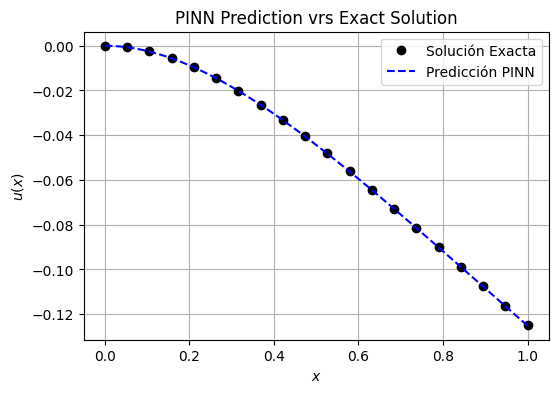

In [7]:
x_values_pinn = np.linspace(0,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(0,1,20).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'ok',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--b',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()

# Diferencia entre model.predict and model.net

In [8]:
X_test = np.array([[0.1],[0.2],[0.3]])
X_test

array([[0.1],
       [0.2],
       [0.3]])

In [9]:
predictions = model.predict(X_test)
predictions

array([[-0.00236212],
       [-0.00876699],
       [-0.01838268]], dtype=float32)

In [10]:
print("Ambos, entrada y salida son tipo numpy= ", type(predictions))

Ambos, entrada y salida son tipo numpy=  <class 'numpy.ndarray'>


Pero model.predict no permite calcular derivadas o gradientes


> model.net <br>
**Permite aceder a la red neuronal como una función**<br>
Esto implica que se pueden calcular gradientes despues de que el entrenamiento se ha hecho.<br>

Es util cuando se necesita más control y flexibilidad. Da acceso directo a la red neuronal subyacente. <br>
Por ejemplo:

In [15]:
# Test data as a pytorch tensor with requires_grad = True
input_tensor = tr.tensor([[0.1],[0.2],[0.3]], dtype=tr.float32, requires_grad = True)
print("Type=",input_tensor)

Type= tensor([[0.1000],
        [0.2000],
        [0.3000]], requires_grad=True)


In [18]:
outputs = model.net(input_tensor)
outputs

tensor([[-0.0024],
        [-0.0088],
        [-0.0184]], grad_fn=<AddmmBackward0>)

In [19]:
# Esta línea es clave en PyTorch para calcular gradientes usando el sistema de autograd 
# (diferenciación automática).
outputs.mean().backward()

# outputs.sum() = y1 + y2 + y3, donde cada yi es el resultado de aplicar la red neuronal a cada entrada xi.
# .backward() solo puede llamarse sobre un escalar (una sola salida). 
#             Si se quiere computar gradientes respecto a un vector de salidas, 
#             se debe reducir (por ej, con .sum() o definir un vector de pesos para multiplicación).


print("Gradientes = ",input_tensor.grad)

Gradientes =  tensor([[-0.0603],
        [-0.1086],
        [-0.1462]])


Lo que hace .sum().backward es lo siguiente:

- $$\frac{∂(y1 + y2 + y3)}{∂x} = \frac{∂(y1+y2+y3)}{∂x1},\frac{∂(y1+y2+y3)}{∂x2},\frac{∂(y1+y2+y3)}{∂x3}$$

Y lo devuelve como un tensor 
> input_tensor.grad = tensor([[dy1/dx1 + dy2/dx1 + dy3/dx1],<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[dy1/dx2 + dy2/dx2 + dy3/dx2], <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[dy1/dx3 + dy2/dx3 + dy3/dx3]])<br>

Pero como net es una *función escalar por entrada (1→1)*, cada yi depende solo de xi (no de los otros).
Entonces, en la práctica:
$$\frac{∂(y1+y2+y3)}{∂x1}=\frac{∂y1}{∂x1},\qquad \frac{∂(y1+y2+y3)}{∂x2}=\frac{∂y2}{∂x2},\qquad\frac{∂(y1+y2+y3)}{∂x3}=\frac{∂y3}{∂x3}$$

Y por eso el gradiente es:

>input_tensor.grad = [[dy1/dx1],
                     [dy2/dx2],
                     [dy3/dx3]]


- El en caso de usar **.mean()** en lugar de .sum(), los gradientes serán exactamente los mismos pero divididos por 3, o en casos más generales, por N, el tamaño del arreglo.




### net es una función escalar por entrada (1→1), cada yi depende solo de xi (no de los otros).

input_tensor es un tensor con forma (3,1), es decir, 3 muestras, cada una con 1 valor:
<code>
    input_tensor = [[x1],
                [x2],
                [x3]]
</code>

Cuando se computa outputs = net(input_tensor) cada muestra xi se procesa por separado y la red devuelve 3 salidas, una para cada muestra: [y1, y2, y3]. $$y_i=f(x_i)$$

Entonces $y_1$ no depende de $x_2$ ni $x_3$ porque la red procesa las muestras en batch, pero no mezcla información entre ellas. Cada fila de input_tensor es una muestra independiente.

# <code>error</code> Method of dirichlerBC

Acá la condición de frontera es $$u(0)=0$$
Por lo que es suficiente con model.predict porque no necesitamos ninguna derivada.

In [22]:
X_boundary = np.array([[0.0]])

inputs = tr.tensor(X_boundary, dtype=tr.float32)

outputs = tr.tensor(model.predict(X_boundary),dtype=tr.float32)

beg, end = 0,len(X_boundary)

residual_left = bc_dbc.error(X_boundary,inputs,outputs,beg,end)
mse_residual = tr.mean(residual_left**2)

print("MSE of boundary residual for Dirichlet condition:")
print(mse_residual.item())

mse_residual_value = mse_residual.item()

MSE of boundary residual for Dirichlet condition:
3.508413559671908e-10


# <code>error</code>  Method of NewmannBC

> error(X,inputs,outputs,beg,end,aux_var=None

- X es un arreglo de numpy
- input/output son tensores

DeepXDE pide X_numpy y X_tensor porque los usa para propósitos distintos:
uno para evaluar condiciones de frontera (funciones NumPy), y otro para calcular derivadas automáticas (con PyTorch/TF/etc.).

Separación clara: derivadas con tensor, funciones definidas por el usuario con numpy. Compatible con múltiples backends. Uno decide cuándo romper o mantener el grafo o cuando pasar a GPU o a CPU.

In [33]:
print(tr.cuda.is_available())
# Si eso imprime False, no se puede usar .to("cuda") hasta que se solucione el problema de drivers o hardware.

False


In [34]:
#X_test = tr.tensor(np.array([[0.0]]), dtype = tr.float32, requires_grad = True).to("cuda")
X_test = tr.tensor(np.array([[0.0]]), dtype = tr.float32, requires_grad = True)

# This tensor necesita ser diferenciable

In [35]:
net = model.net
outputs = net(X_test)


residual_nbc = bc_nbc.error(
    #X_test.cpu().detach().numpy,
    X_test.detach().numpy(),      # <-- Se convierte en un arreglo de numpy, pero para ello 
                                  #     se desancla de el computational graph. En este ya no se pueden
                                  #     calcular derivadas.
    X_test,
    outputs,
    0,
    len(X_test),
)

In [36]:
mse_residual_nbc = tr.mean(residual_nbc**2)

print(f"Residual for NeumannBC:{residual_nbc.detach().numpy()}")
print(f"MSE of Boundary residual:{mse_residual_nbc.item()}")


Residual for NeumannBC:[[3.9875507e-05]]
MSE of Boundary residual:1.590056086797631e-09


# <code>error</code>  Method of OperatorBC

In [40]:

X_test = tr.tensor(np.array([[1.0]]), dtype = tr.float32, requires_grad=True)#.to("cuda")

net = model.net
outputs = net(X_test)

residual_obc1 = bc_obc1.error(
    X_test.detach().numpy(),      # <-- Se convierte en un arreglo de numpy
    X_test,
    outputs,
    0,
    len(X_test),
)
#bc_obc1
residual_obc2 = bc_obc2.error(
    X_test.detach().numpy(),      # <-- Se convierte en un arreglo de numpy
    X_test,
    outputs,
    0,
    len(X_test),
)

In [44]:
mse_residual_obc1 = tr.mean(residual_obc1**2)
mse_residual_obc2 = tr.mean(residual_obc2**2)


print(f"Residual for OperatorBC_1 (2° derivative):{residual_obc1.detach().numpy()}")
print(f"MSE of Boundary residual: {mse_residual_obc1.item()}")

print()
print()
print(f"Residual for OperatorBC_2 (3° derivative):{residual_obc2.detach().numpy()}")
print(f"MSE of Boundary residual: {mse_residual_obc2.item()}")

Residual for OperatorBC_1 (2° derivative):[[0.00020458]]
MSE of Boundary residual: 4.18536991730889e-08


Residual for OperatorBC_2 (3° derivative):[[-7.3872507e-06]]
MSE of Boundary residual: 5.45714723410029e-11
